In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from rdkit.Chem import MolFromSmiles, MolToSmiles, molzip, RWMol
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from itertools import product, combinations_with_replacement
from pickle import load
from scipy.stats import pearsonr, kendalltau
from matplotlib.offsetbox import AnnotationBbox

import sys
sys.path.append('../')
import FragShapley

/home/jannik/Documents/studies/phd/03_work/20_FragShapley/FragShapley/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")

In [3]:
models = ['RF', 'GCN', 'MPNN']

# 0. Load Shapley Values

In [4]:
# only select a single dataset
dataset_of_interest = 'esol_delaney'
model_of_interest = 'RF'

# consider dummy atoms
remove_dummies = False

files = [f'../3_solubility/{model.lower()}_regression_solubility/df_explanation.pkl' for model in models]
df_sol = pd.concat((pd.read_pickle(sol_file) for sol_file in files))

df_sol = df_sol.loc[df_sol.dataset == dataset_of_interest]
df_sol = df_sol.loc[df_sol.model == model_of_interest]

# 1. Get List of Fragments and their Shapley Values ACROSS all splits

In [5]:
# obtain SMILES of fragments
df_sol['fragments'] = df_sol.smiles.apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=remove_dummies))

In [6]:
# get the values of the Explainer as a list (currently only available as dict)
df_sol['fragExplainer_shapley_values'] = df_sol.fragExplainer_result.apply(lambda x: list(x.values()))
# create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
df_fragments = df_sol[['fragments', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)

df_fragments = df_fragments.groupby('fragments').agg([len, 'mean', 'std', list]) # will throw warning veacuse of error when calculating std for a single measurement
df_fragments = df_fragments.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_fragments.columns = [col[0] if col[1]=='' else col[1] for col in df_fragments.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std
df_fragments

,fragments,len,mean,std,list
0,*=C(C(=*)c1ccc(O)cc1)c1ccc(O)cc1,1,-0.088043,NaN,[-0.08804250000000075]
1,*=C(C)C,8,0.183889,0.254793,"[0.676297976190475, 0.30733044642857105, 0.274..."
2,*=C(C)OP(=O)(OC)OC,1,0.787518,NaN,[0.7875179861111107]
3,*=C(C)OP(=S)(NCC)OC,1,-0.901227,NaN,[-0.9012270833333317]
4,*=C(C=O)CC,1,0.825186,NaN,[0.8251856250000015]
...,...,...,...,...,...
994,c1ccoc1,1,-0.235455,NaN,[-0.23545511904761818]
995,c1ccsc1,1,-0.209795,NaN,[-0.2097949999999995]
996,c1cnc2c(c1)ccc1ncccc12,1,-3.280024,NaN,[-3.280024499999998]
997,c1cnc2ncncc2n1,1,0.707877,NaN,[0.7078774999999988]


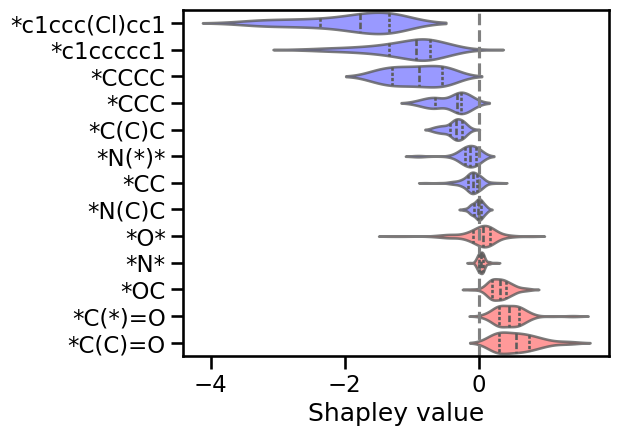

In [7]:
# now get the smiles to consider
min_n = 20

# get list of SMILES of the fragments that appear at least min_n times
smiles_to_consider = df_fragments.query('len >= @min_n').fragments.to_list()
# get their mean values to order them in the plot afterwards
mean_vals = df_fragments.query('fragments in @smiles_to_consider')['mean'].values
sort_idx = np.argsort(mean_vals)
sm_ordered = np.array(smiles_to_consider)[sort_idx]

fig, axs = plt.subplots(1, 1, figsize=(5.5, 4.5))
axs.axvline(x=0, color='gray', ls='--') # line to indicate change from positive to negative influence

sns.violinplot(df_fragments.query('len >= @min_n').explode('list'), # need to explode to get the list untangled
               x='list',
               y='fragments',
               inner='quart',
               density_norm='width',
               order=sm_ordered, # order them correctly
               ax=axs
               )

# color the violins individually based on whether their mean contribution is above zero or not
col_negative = (.5,.5,1) #sns.color_palette()[4]
col_positive = (1,.5,.5) #sns.color_palette()[0]
color_list = list(col_negative if mv < 0 else col_positive for mv in mean_vals[sort_idx])
for violin, color in zip(axs.collections, color_list):
    violin.set_facecolor(color)
    violin.set_alpha(0.8)

# fix labels
axs.set_ylabel('')
axs.set_xlabel('Shapley value')

fig.savefig(os.path.join(fig_folder, f'1_solubility_dataset_{dataset_of_interest}_model_{model_of_interest}_min_{min_n}.pdf'), 
            bbox_inches='tight',
            )
fig.savefig(os.path.join(fig_folder, f'1_solubility_dataset_{dataset_of_interest}_model_{model_of_interest}_min_{min_n}.svg'), 
            bbox_inches='tight',
            )

In [8]:
# need to check expected value if we can actually compare across different splits
df_sol.fragExplainer_expected_value.unique(), df_sol.fragExplainer_expected_value.agg(['mean', 'std'])

(array([-1.06374   , -1.20738   , -1.2961    , -1.476665  , -1.01001901]),
 mean   -1.210781
 std     0.167354
 Name: fragExplainer_expected_value, dtype: float64)

# 2. Molecular "Optimization"

In [9]:
# need to use only a single split now
split_of_interest = 0

# need to get train/test instances now
df_perf = pd.read_pickle(f'../3_solubility/{model_of_interest.lower()}_regression_solubility/df_performance.pkl')
df_all = pd.read_csv(f'../0_datasets/regression/{dataset_of_interest}.csv')
df_expl = pd.read_pickle(f'../3_solubility/{model_of_interest.lower()}_regression_solubility/df_explanation.pkl').query('dataset == @dataset_of_interest and split == @split_of_interest')

In [10]:
train_indices = df_perf.loc[(df_perf.split == split_of_interest) & (df_perf.dataset == dataset_of_interest)].iloc[0].train_index
train_smiles = df_all.nonstereo_aromatic_smiles.to_numpy()[train_indices]

## 2.1 Shapley Values per Fragment

Same as above

In [11]:
df_expl['fragments'] = df_expl.smiles.apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=remove_dummies))

In [12]:
# get the values of the Explainer as a list (currently only available as dict)
df_expl['fragExplainer_shapley_values'] = df_expl.fragExplainer_result.apply(lambda x: list(x.values()))
# create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
df_frag = df_expl[['fragments', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)
df_frag = df_frag.groupby('fragments').agg([len, 'mean', 'std']) # will throw warning because of error when calculating std for a single measurement
df_frag = df_frag.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_frag.columns = [col[0] if col[1]=='' else col[1] for col in df_frag.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std
df_frag

,fragments,len,mean,std
0,*=C(C)OP(=S)(NCC)OC,1,-0.901227,NaN
1,*=C(CC)c1ccc(O)cc1,2,-0.700226,0.00000
2,*=CC,1,-0.260975,NaN
3,*=CC=O,1,1.19338,NaN
4,*C(*)=O,17,0.421101,0.20164
...,...,...,...,...
258,c1ccc2ocnc2c1,1,-0.677895,NaN
259,c1ccccc1,1,-0.225487,NaN
260,c1cnc2c(c1)ccc1ncccc12,1,-3.280024,NaN
261,c1cnc2ncncc2n1,1,0.707877,NaN


In [13]:
min_appearance = 3
df_frag = df_frag.loc[df_frag['len'] >= min_appearance]
df_frag.shape

(24, 4)

In [14]:
df_frag = df_frag.loc[df_frag.fragments.apply(lambda x: FragShapley.utils.filter_n_attachment(x, n=1))]
df_frag

,fragments,len,mean,std
9,*C(=O)CC,3,0.36335,0.177867
13,*C(C)(C)C,4,-0.969442,0.253206
15,*C(C)=O,8,0.527315,0.278102
16,*C(C)C,9,-0.401696,0.105572
22,*C(F)(F)F,4,-0.725029,0.164434
23,*C(N)=O,4,0.794605,0.025611
48,*CC,29,-0.080285,0.108667
56,*CC=C,6,-0.25326,0.071610
57,*CCC,4,-0.809853,0.090667
60,*CCCC,6,-1.174054,0.316144


## 2.2 Define Core and Assemble Combinations

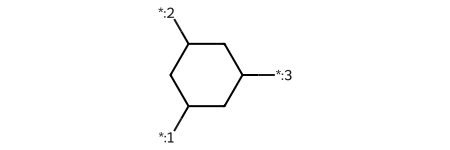

In [15]:
# choose an appropriate core
n_attach_smiles = {1: 'C1C([*:1])CCC(C(C)C)C1(O)',
                   2: 'C1CC([*:1])CC([*:2])C1',
                   3: 'C1([*:3])CC([*:1])CC([*:2])C1',
                   }

n_attach = 3
core_smiles = n_attach_smiles[n_attach]
core_mol = MolFromSmiles(core_smiles)
attachments_symmetrically_equivalent = {1: False,
                                        2: True,
                                        3: True}[n_attach]
core_mol

In [16]:
# generate list of tuples containing the substituent and the mean and std contribution
frag_mean = [(smiles, mean) for smiles, mean in zip(df_frag.fragments, df_frag['mean'], )]

In [17]:
# choose correct iterator depending on symmetry
if attachments_symmetrically_equivalent:
    iterator = combinations_with_replacement(frag_mean, n_attach)
else:
    iterator = product(frag_mean, repeat=n_attach)

def add_attachment_point_number_to_connection_point(smiles, number):
    return smiles.replace('*', f'[*:{number}]')

result_list = []

# iterate over all combinations
for out in iterator:
    smiles = [i[0] for i in out]
    means = [i[1] for i in out]
    smiles_processed = [add_attachment_point_number_to_connection_point(sm, idx+1) for idx, sm in enumerate(smiles)] # add correct attachment point number (+1 since attachment points start numbering from 1)
    tmp_mol = RWMol(core_mol) # create new mol, editable
    [tmp_mol.InsertMol(MolFromSmiles(sm)) for sm in smiles_processed] # insert all fragments
    tmp_mol = molzip(tmp_mol) # zip it together
    result_list.append((MolToSmiles(tmp_mol, canonical=True), means))

In [18]:
df_combs = pd.DataFrame({'smiles': [i[0] for i in result_list],
                         'means': [i[1] for i in result_list],
                         })
df_combs.shape

(680, 2)

In [19]:
# remove duplicates
df_combs = df_combs.drop_duplicates(subset='smiles')
# sum mean contribution
df_combs['sum_mean_attributions'] = df_combs.means.apply(sum)
df_combs.shape

(680, 3)

In [20]:
# check if created molecules are in training set
df_combs = df_combs.query('smiles not in @train_smiles')
df_combs.shape

(680, 3)

## 2.3 Load Model and get Predictions

In [21]:
core_hydrogen = FragShapley.utils.remove_dummy_atoms(core_mol)

if model_of_interest.lower() == 'rf':
    with open(f'../3_solubility/rf_regression_solubility/models/model_rfr_{dataset_of_interest}_split_{split_of_interest}.pkl', 'rb') as f:
        model = load(f)
    

    mfpgen = GetMorganGenerator(radius=2,
                                fpSize=2048,
                                )
    fps = np.stack([mfpgen.GetFingerprintAsNumPy(MolFromSmiles(sm)) for sm in df_combs.smiles])
    df_combs['prediction'] = model.predict(fps)

    # add default value of no substituents
    fp_core_hydrogens = mfpgen.GetFingerprintAsNumPy(core_hydrogen)
    pred_core_hydrogens = model.predict(fp_core_hydrogens.reshape(1, -1))[0]

else:
    raise NotImplementedError(f"The model you chose ({model_of_interest}) is not yet implemented to load and predict here!")

In [22]:
# save molecule as svg
for at in core_mol.GetAtoms():
    if at.GetAtomMapNum() != 0:
        at.SetAtomMapNum(0)

# Compute 2D coordinates (important!)
rdDepictor.Compute2DCoords(core_mol)
# Create SVG drawer
drawer = rdMolDraw2D.MolDraw2DSVG(300, 300)
# Draw molecule
drawer.DrawMolecule(core_mol)
drawer.FinishDrawing()
# Get SVG text
svg = drawer.GetDrawingText()

# Save to file
with open(os.path.join(fig_folder, f'molecules_solubility/1_solubility_dataset_{dataset_of_interest}_n_{n_attach}_molecule_core.svg'), "w") as f:
    f.write(svg)

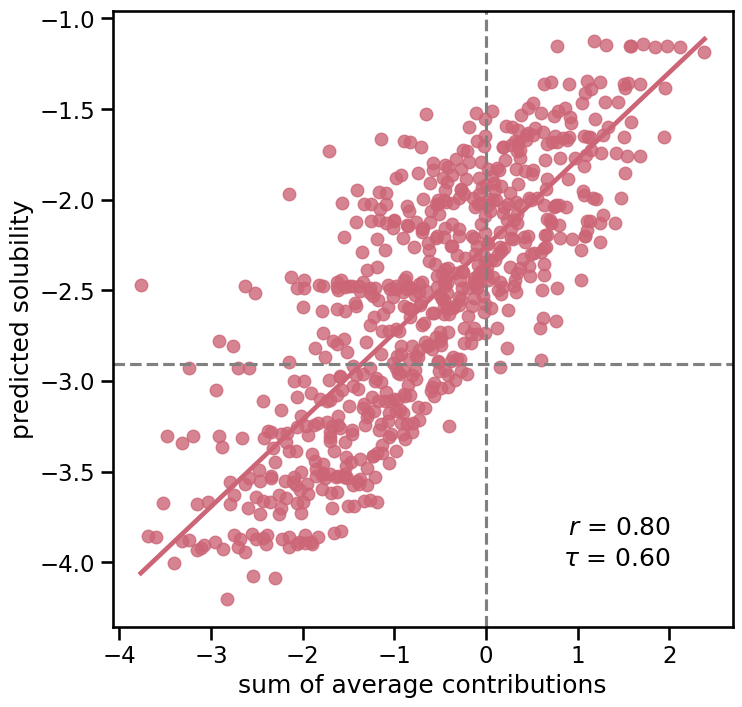

In [23]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8))
sns.regplot(data=df_combs,
            x='sum_mean_attributions',
            y='prediction',
            ci=None,
            ax=axs)

axs.set_xlabel('sum of average contributions')
axs.set_ylabel('predicted solubility')


axs.axhline(pred_core_hydrogens, color='grey', ls='--')
axs.axvline(0, color='gray', ls='--')

# add statistics
pearson_stat = pearsonr(df_combs.sum_mean_attributions, df_combs.prediction)
kendall_stat = kendalltau(df_combs.sum_mean_attributions, df_combs.prediction)

axs.text(x=0.90,
         y=0.15,
         s='$r$'+f' = {pearson_stat.statistic:.2f}',
         transform=axs.transAxes,
         ha='right')
axs.text(x=0.90,
         y=0.10,
         s='$\\tau$'+f' = {kendall_stat.statistic:.2f}',
         transform=axs.transAxes,
         ha='right')

fig.savefig(os.path.join(fig_folder, f'1_solubility_dataset_{dataset_of_interest}_model_{model_of_interest}_split_{split_of_interest}_n_{n_attach}.svg'), 
            bbox_inches='tight',
            )

In [24]:
# Add the molecule later by hand (inkscape)

In [25]:
print(f'Pearson: {pearson_stat.pvalue:.2e}')
print(f'Kendall: {kendall_stat.pvalue:.2e}')

Pearson: 2.78e-150
Kendall: 1.77e-120


## 2.3 Visualize some predictions

In [26]:
# simply use a single split here and pick some good examples

# only correctly predicted and mutagenic compounds
df_expl['abs_delta'] = df_expl.apply(lambda x: np.abs(x.y_true - x.y_pred), axis=1)
df_plot = df_expl.query('abs_delta < 0.3').copy()

# get number of fragments, more interesting to plot compounds with more than two fragments
df_plot['n_fragments'] = df_plot.fragments.apply(len)
df_plot = df_plot.loc[df_plot.n_fragments > 2]
df_plot

,model,dataset,split,smiles,y_true,y_pred,fragExplainer_result,fragExplainer_expected_value,shap_result,shap_expected_value,atom_id_to_bits,frag_to_atom_ids,fragments,fragExplainer_shapley_values,abs_delta,n_fragments
6,RF,esol_delaney,0,CCNC(=S)NCC,-1.460,-1.214008,"{0: -0.14974333333333312, 1: 0.149219166666664...",-1.06374,"[0.0, 0.01473801443438333, 0.0, 0.0, 0.0, -1.2...",-3.204293,"{1: [80, 1624, 1726], 6: [80, 1624, 1726], 4: ...","{0: [0, 1], 1: [2, 3, 4, 5], 2: [6, 7]}","[*CC, *NC(=S)N*, *CC]","[-0.14974333333333312, 0.14921916666666493, -0...",0.245992,3
66,RF,esol_delaney,0,C=CCC1(CC=C)C(=O)NC(=O)NC1=O,-2.077,-1.785589,"{0: -0.2055991666666659, 1: -0.310650666666668...",-1.06374,"[0.0, 0.010904762298722339, 0.0, 0.0, 0.0, -1....",-3.204293,"{2: [80, 426, 1455], 4: [80, 426, 1455], 3: [2...","{0: [0, 1, 2], 1: [3, 7, 8, 9, 10, 11, 12, 13,...","[*CC=C, *C1(*)C(=O)NC(=O)NC1=O, *CC=C]","[-0.2055991666666659, -0.31065066666666863, -0...",0.291411,3
68,RF,esol_delaney,0,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,-2.658,-2.548152,"{0: -0.11230350000000046, 1: -0.14301299999999...",-1.06374,"[0.0, -0.07196692324907503, 0.0, 0.0, 0.0, -1....",-3.204293,"{5: [1, 1847, 1860], 1: [80, 1015, 1351], 3: [...","{0: [0, 1], 1: [2, 8, 9, 10, 11, 12, 13, 14, 1...","[*CC, *C1(*)C(=O)NC(=O)NC1=O, *CCC(C)C]","[-0.11230350000000046, -0.1430129999999994, -1...",0.109848,3
116,RF,esol_delaney,0,CC(=O)OCC(=O)C1CCC2C3CCC4=CC(=O)CCC4(C)C3CCC12C,-4.630,-4.661735,"{0: 0.15186270833333212, 1: -0.142115208333334...",-1.06374,"[0.0, 0.011210120819621352, 0.0, 0.0, 0.0, -2....",-3.204293,"{22: [7, 519, 1019], 20: [16, 1060, 1884], 4: ...","{0: [0, 1, 2], 1: [3], 2: [4, 5, 6], 3: [7, 8,...","[*C(C)=O, *O*, *CC(*)=O, *C1CCC2C3CCC4=CC(=O)C...","[0.15186270833333212, -0.14211520833333416, 0....",0.031735,4
120,RF,esol_delaney,0,CC(C)OC(C)C,-1.100,-1.273903,"{0: -0.3602870833333337, 1: 0.5104116666666649...",-1.06374,"[0.0, -0.22465475474183053, 0.0, 0.0, 0.0, -8....",-3.204293,"{1: [1, 553, 1978], 4: [1, 553, 1978], 0: [283...","{0: [0, 1, 2], 1: [3], 2: [4, 5, 6]}","[*C(C)C, *O*, *C(C)C]","[-0.3602870833333337, 0.5104116666666649, -0.3...",0.173903,3
128,RF,esol_delaney,0,CCOc1ccc(NC(N)=O)cc1,-2.170,-2.347475,"{0: -0.050988541666666484, 1: 0.17631999999999...",-1.06374,"[0.0, 0.01328256903561595, 0.0, 0.0, 0.0, -5.4...",-3.204293,"{2: [69, 695, 1452], 1: [80, 237, 1238], 3: [1...","{0: [0, 1], 1: [2], 2: [3, 4, 5, 6, 11, 12], 3...","[*CC, *O*, *c1ccc(*)cc1, *N*, *C(N)=O]","[-0.050988541666666484, 0.17631999999999895, -...",0.177475,5
137,RF,esol_delaney,0,CN(C)C(=O)Nc1cccc(C(F)(F)F)c1,-3.430,-3.253388,"{0: -0.023759166666667025, 1: 0.76703395833333...",-1.06374,"[0.0, 0.010239493718702307, 0.0, 0.0, 0.0, -1....",-3.204293,"{11: [114, 809, 1260], 6: [184, 191, 1380], 3:...","{0: [0, 1, 2], 1: [3, 4], 2: [5], 3: [6, 7, 8,...","[*N(C)C, *C(*)=O, *N*, *c1cccc(*)c1, *C(F)(F)F]","[-0.023759166666667025, 0.7670339583333328, 0....",0.176612,5
145,RF,esol_delaney,0,OCC1OC(n2cnc3c(O)ncnc32)C(O)C1O,-1.230,-1.471445,"{0: 0.5816790000000003, 1: 0.286758999999999, ...",-1.06374,"[0.0, 0.011266885910794713, 0.0, 0.0, 0.0, -1....",-3.204293,"{3: [75, 656, 1921], 1: [80, 1516, 1764], 9: [...","{0: [0, 1], 1: [2, 3, 4, 15, 16, 17, 18], 2: [...","[*CO, *C1OC(*)C(O)C1O, *n1cnc2c(O)ncnc21]","[0.5816790000000003, 0.286758999999999, -1.276...",0.241445,3
151,RF,esol_delaney,0,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,-0.244,-0.200455,"{0: 0.3995356666666663, 1: 0.3502660833333333,...",-1.06374,"[0.0, 0.011342979326287831, 0.0, 0.0, 0.0, -1....",-3.204293,"{1: [80, 1516, 1764], 8: [80, 1516, 1764], 13:...","{0: [0, 1], 1: [2, 3, 4, 17, 18, 19, 20, 21, 2...","[*CO, *C1OC(*)C(O)C(O)C1O, *O*, *C1OC(O)C(O)C(...","[0.3995356666666663, 0.3502660833333333, -0.56...",0.043545,5
157,RF,esol_delaney,0,COCCCNc1nc(NC(C)C)nc(SC)n1,-2.928,-3.063066,"{0: 0.35936510714285813, 1: -0.453181420634921...",-1.06374,"[0.0, -0.06793728372629261, 0.0, 0.0, 0.0, -2....",-3.204293,"{10: [1, 265, 1028], 2: [13, 80, 4

In [27]:
model = 'RF'
row_indices = {'RF': [2, 5, 6, 7, 11, 12]} # 2, 5, 6, 7, 11, 12

df_tmp = df_plot.loc[df_plot.model == model]
for idx in row_indices[model]:
    row = df_tmp.iloc[idx]
    contributions = FragShapley.visualization.get_atom_contribution_from_result_dict(row.smiles,
                                                                                     results_dict=row.fragExplainer_result,
                                                                                     frag_to_atom_ids=row.frag_to_atom_ids)
    out = FragShapley.visualization.visualize_contributions_new(smiles=row.smiles,
                                                                contributions=row.fragExplainer_result.values(),
                                                                frag_to_atom_ids=row.frag_to_atom_ids,
                                                                min=-5,
                                                                max=5,
                                                                colormap='bwr')
    with open(os.path.join(fig_folder, f"molecules_solubility/1_solubility_ex_mol_{model}_idx_{idx}.svg"), "w") as f:
        f.write(out.data)